In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison
import seaborn as sb
import statsmodels.api as sm


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# Ajuste de coeficientes de matriz IP utilizando datos de trabajadores asegurados
# Chunk 2: Definición de sectores + carga y preprocesamiento inicial
# ============================================================

# ------------------------------------------------------------------
# 1) Nombres de sectores (mapeo visual para códigos sectoriales)
# ------------------------------------------------------------------
sector_names = [
    "Industrias Agropecuaria",
    "Industrias Extractivas",
    "",  # Hay un sector sin etiqueta. Debido a que en la lista oficial de sectores del IMSS,
         # Industrias de transformación se repite dos veces, entonces para que no haya error.
    "Industrias de Transformacion",
    "Industrias de la Construccion",
    "Ind. Electrica y Suministro Agua pot",
    "Comercio",
    "Transporte y comunicaciones",
    "Servicios para empresa, personal, hogar",
    "Servicios sociales"
]

# Nota técnica:
# - Si los códigos sectoriales inician en 1 (en lugar de 0), esta lista puede desfasarse.
# - Confirmar más adelante contra los valores reales en `sector_economico_1` y `sector_economico_2`.

# ------------------------------------------------------------------
# 2) Carga de datos
# ------------------------------------------------------------------

# Si se monta Google Drive, ajustar `DATA_PATH` adecuadamente.
DATA_PATH = "/content/drive/MyDrive/PAP/HW_Datos_Jal.csv"

data = pd.read_csv(DATA_PATH)

# TODO (INVESTIGAR): Confirmar qué representa el dataset "HW_Datos_Jal.csv":
# - Fuente (IMSS, INEGI, otra)
# - Cobertura geográfica (¿Jalisco?)
# - Cobertura temporal
# - Definición de variables, especialmente HWES1 y Año.

# ------------------------------------------------------------------
# 3) Copia de trabajo + renombre de variable clave
# ------------------------------------------------------------------
data_hw = data.copy()

# HWES1 parece ser la variable central que luego interpretan como "ta".
# TODO (INVESTIGAR): ¿Qué es HWES1 exactamente?
# Posibles hipótesis:
# - "Trabajadores asegurados" (IMSS) en cierto sector
# - Alguna medida de empleo formal / asegurados
data_hw["ta"] = data_hw["HWES1"]
data_hw = data_hw.drop(columns=["HWES1"])

# ------------------------------------------------------------------
# 4) Selección de variables relevantes + limpieza de nulos
# ------------------------------------------------------------------
cols_needed = ["sector_economico_1", "sector_economico_2", "ta", "Año"]

# Filtramos a las columnas necesarias y quitamos filas con NA en esas columnas.
selected_data = data_hw.loc[:, cols_needed].dropna()

# - sector_economico_1 y sector_economico_2:
#   Sectores economicos y grupos en los que se dividen

# ------------------------------------------------------------------
# 5) Tratamiento del tiempo y filtro temporal (post-2010-01-31)
# ------------------------------------------------------------------
# Convertimos explícitamente la columna de fecha.
# Si no es una fecha, esto revelará errores temprano (mejor que errores silenciosos).
selected_data["Año"] = pd.to_datetime(selected_data["Año"], errors="coerce")

# Eliminamos filas donde la fecha no pudo convertirse
selected_data = selected_data.dropna(subset=["Año"])

# Aplicamos filtro temporal
cutoff_date = pd.Timestamp("2010-01-31")
selected_data = selected_data[selected_data["Año"] > cutoff_date]  # No es necesario aplicar filtro porque los datos comienzan en febrero 2010

# Vista rápida
selected_data.head()

,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878.000000,2010-02-28
1,0.0,1.0,40878.000000,2010-03-31
2,0.0,1.0,40913.125000,2010-04-30
3,0.0,1.0,40804.703125,2010-05-31
4,0.0,1.0,40651.132161,2010-06-30


In [4]:
def get_sector_data_covars(data: pd.DataFrame):
    # Se hace una copia del DataFrame para evitar modificar el original fuera de la función
    data = data.copy()

    # ------------------------------------------------------------
    # 1) "Main sector data": agregación por sector principal y tiempo
    # ------------------------------------------------------------
    # Agrupa por (Año, sector_economico_1) y suma las columnas numéricas dentro de cada grupo.
    # Resultado esperado: una fila por (Año, sector_economico_1) con el total de 'ta' (y cualquier
    # otra variable numérica que exista en el DataFrame).
    #
    # NOTA: aquí se usa .sum() sin seleccionar columnas, así que sumará todas las numéricas.
    sector_data = data.groupby(["Año", "sector_economico_1"])\
        .sum() \
        .reset_index() \
        .drop("sector_economico_2", axis=1) \
        .sort_values(by=["sector_economico_1", "Año"])

    # ------------------------------------------------------------
    # 2) "Groups data": agregación por sector principal, sector secundario y tiempo
    # ------------------------------------------------------------
    # Agrupa por (Año, sector_economico_1, sector_economico_2) y suma columnas numéricas.
    # Resultado: una fila por combinación sector-sector en cada Año, con su 'ta' agregado.
    grouped_data = data.groupby(["Año", "sector_economico_1", "sector_economico_2"])\
        .sum() \
        .reset_index()

    # ------------------------------------------------------------
    # 3) Base de retorno
    # ------------------------------------------------------------
    # ret_data empieza siendo igual a sector_data (actividad agregada del sector principal por Año)
    # y luego se le agregan columnas "covar_*" (covariables) para cada grupo sectorial.
    ret_data = sector_data.copy()

    # print(ret_data)  # útil para depurar si se quiere ver la estructura base

    # ------------------------------------------------------------
    # 4) Identificar sectores principales disponibles
    # ------------------------------------------------------------
    # Obtiene la lista de sectores únicos en sector_economico_1 para iterar sector por sector.
    sectors_set = sorted(set(sector_data.sector_economico_1))

    # ------------------------------------------------------------
    # 5) Agregar covariables por sector y "grupo"
    # ------------------------------------------------------------
    # Por cada sector principal:
    #   - se identifican los grupos (sector_economico_2) que aparecen asociados a ese sector
    #   - se obtiene la serie de 'ta' para cada par (sector, grupo) a lo largo del tiempo
    #   - se crea una nueva columna en ret_data con nombre covar_s{sector}_g{grupo}

    for sector in sectors_set:
        # Lista de grupos asociados al sector principal "sector"
        groups_set = sorted(set(
            grouped_data[(grouped_data["sector_economico_1"] == sector)]["sector_economico_2"]
        ))

        for group in groups_set:
            # Extrae la serie de 'ta' para el par (sector_economico_1=sector, sector_economico_2=group)
            # a través del tiempo (Año).
            employments_per_group = grouped_data[
                (grouped_data["sector_economico_1"] == sector) &
                (grouped_data["sector_economico_2"] == group)
            ]["ta"]

            try:
                # Convierte la serie a lista y la repite 10 veces.
                # Este paso NO alinea por Año; es un método para forzar dimensión/longitud
                # para que el vector encaje en el DataFrame ret_data.

                covar_col = list(employments_per_group.values) * 10

                # Crea una nueva columna con el patrón covar_s{sector}_g{group}
                # Interpretación: esta columna sirve como covariable (posible explicativa) asociada
                # al empleo del grupo "group" dentro del sector principal "sector".
                ret_data[f"covar_s{int(sector)}_g{int(group)}"] = covar_col

            except Exception as e:
                # Si la asignación falla (normalmente por diferencias de longitud entre covar_col y ret_data),
                # se imprime un mensaje y se omite ese grupo para ese sector.
                #
                # NOTA: Esto puede provocar que falten covariables en el resultado final sin detener el programa.
                print(
                    f"Skipping sector {sector_names[int(sector)]} group {group}, "
                    f"it does not contain the same amount of rows: {len(employments_per_group)}"
                )

    # ------------------------------------------------------------
    # 6) Salida de la función
    # ------------------------------------------------------------
    # Devuelve ret_data: una tabla por (Año, sector_economico_1) con 'ta' agregado
    # + columnas covar_sX_gY que representan series de empleo por grupo (replicadas).
    return ret_data


In [ ]:
sector_df = get_sector_data_covars(selected_data)
#sector_df['covar_s0_g1']
sector_df.tail()

,Año,sector_economico_1,ta,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
1579,2023-03-31,9.0,273669.743647,89530.457437,22528.066853,434.680343,509.319634,42.073018,1446.215281,15.041679,...,6140.205500,30786.473565,50523.641274,17944.434183,47863.085964,47444.122317,30811.080943,5889.546765,189386.876760,138.116863
1589,2023-04-30,9.0,274092.587662,89898.480044,22589.105735,437.193662,498.889649,42.361643,1449.372978,14.998276,...,6179.863604,30984.662167,50755.656221,18064.166092,47975.457382,47542.450553,30990.994237,5885.190650,189535.548561,138.403660
1599,2023-05-31,9.0,274502.188176,90125.501709,22646.517996,439.268926,488.602581,42.596574,1451.815770,15.040015,...,6219.035954,31180.051243,50993.712211,18181.200838,48112.271658,47620.848447,31175.202810,5877.349373,189689.984038,138.803508
1609,2023-06-30,9.0,274885.597002,90293.480804,22698.413079,442.007721,478.744140,42.821717,1456.365113,15.121681,...,6253.242789,31378.132441,51254.557536,18301.275803,48229.177006,47678.771428,31357.361027,5868.876482,189841.359703,139.228362
1619,2023-07-31,9.0,275123.238793,90344.085771,22750.312534,444.632399,469.546467,43.079145,1460.641567,15.283277,...,6294.857673,31578.085256,51549.200972,18428.597645,48341.502964,47592.197619,31542.929317,5862.048295,189986.428049,139.635513


In [5]:
# ------------------------------------------------------------
# 1) Construcción del dataset por sector con covariables
# ------------------------------------------------------------
sector_df = get_sector_data_covars(selected_data)

# Las primeras columnas esperadas suelen ser: ["Año", "sector_economico_1", "ta"]

# Tomamos desde la 4ta columna en adelante como covariables (grupos).
covars_df = sector_df.iloc[:, 3:].copy()

# ------------------------------------------------------------
# ¿Por qué cortar a 162 filas?
# Número de observaciones de un mismo sector económico principal
# Se eligen todas las obervaciones desde 2010 hasta 2023, pero solo para el primer sector económico, la agricultura.
# ------------------------------------------------------------
covars_df = covars_df.iloc[:162, :].copy()

# Lista de covariables
covars = list(covars_df.columns)

# ------------------------------------------------------------
# 2) Estimación: para cada covariable c, se estima:
#    c_t = α + Σ_{k≠c} β_k * k_t + error
#
# Esto genera una "matriz" de coeficientes β entre covariables.
# Interpretación: asociación/relación estadística condicional, no flujos insumo-producto.
# ------------------------------------------------------------
covars_df = covars_df.replace([np.inf, -np.inf], np.nan).fillna(0)

rows_coef = []   # filas de coeficientes
rows_pval = []   # filas de p-values
r2_rows  = []    # resumen de R² por regresión

for c in covars:
    # Variable dependiente
    y = covars_df[c]

    # Variables explicativas: todas menos la dependiente
    X = covars_df.drop(columns=[c])

    # Intercepto
    X = sm.add_constant(X, has_constant="add")

    # Modelo OLS + ajuste clásico (NO regularizado)
    mod = sm.OLS(y, X)
    res = mod.fit()   # <- AQUÍ está la corrección clave vs fit_regularized()

    params = res.params.copy()
    pvals  = res.pvalues.copy()

    # Guardar coeficientes y p-values sin la constante
    coef_row = params.drop(labels=["const"], errors="ignore")
    pval_row = pvals.drop(labels=["const"], errors="ignore")

    # Guardar intercepto y su p-value en columnas separadas
    coef_row["intercept"] = params.get("const", np.nan)
    pval_row["intercept_pvalue"] = pvals.get("const", np.nan)

    coef_row.name = c
    pval_row.name = c

    rows_coef.append(coef_row)
    rows_pval.append(pval_row)

    # R² y R² ajustado por cada regresión (cada variable dependiente c)
    r2_rows.append({
        "dep_var": c,
        "nobs": float(res.nobs),
        "r2": float(res.rsquared),
        "r2_adj": float(res.rsquared_adj),
        "f_pvalue": float(res.f_pvalue) if res.f_pvalue is not None else np.nan
    })

coeffs_df  = pd.DataFrame(rows_coef).sort_index(axis=0).sort_index(axis=1)
pvalues_df = pd.DataFrame(rows_pval).sort_index(axis=0).sort_index(axis=1)
r2_df      = pd.DataFrame(r2_rows).set_index("dep_var").sort_index()

# Vista rápida
coeffs_df.head()


,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,NaN,2.781495,-3.458753,-7.104543,-179.192376,2.265814,-364.268138,5.476175,1.191572,-5.778076,...,0.708653,1.623428,-2.107633,0.704252,1.033594,-1.903239,1.099309,-0.205458,-51.143319,-96277.970554
covar_s0_g2,0.066350,NaN,1.800633,-0.710890,45.402387,-2.164332,-3.910244,0.763846,-0.268188,0.440125,...,0.109104,-0.242926,-0.163309,-0.090706,-0.122424,0.276460,-0.741253,0.023952,-10.343583,42473.845127
covar_s0_g3,-0.001273,0.027792,NaN,-0.007238,1.112674,0.237358,-2.895956,-0.118595,-0.006022,-0.009139,...,0.000625,0.016691,0.023521,0.000021,0.012079,-0.034793,0.074229,0.012535,2.082301,-3877.108265
covar_s0_g4,-0.015790,-0.066236,-0.043693,NaN,-8.281417,-0.147475,-4.890157,-0.097981,-0.020889,-0.024040,...,0.052873,-0.027257,-0.066879,0.010675,-0.002884,-0.112419,-0.012664,-0.016230,-0.568444,7245.316894
covar_s0_g5,-0.000116,0.001230,0.001953,-0.002408,NaN,-0.009839,-0.085564,-0.001014,0.001081,0.000506,...,-0.000020,-0.000052,-0.000154,0.000517,-0.000278,-0.000082,0.000159,-0.000638,-0.036296,-16.104273


In [6]:
# ------------------------------------------------------------
# 1) Construcción del dataset por sector con covariables
# ------------------------------------------------------------
sector_df = get_sector_data_covars(selected_data)

# Las primeras columnas esperadas suelen ser: ["Año", "sector_economico_1", "ta"]

# Tomamos desde la 4ta columna en adelante como covariables (grupos).
covars_df = sector_df.iloc[:, 3:].copy()

# ------------------------------------------------------------
# ¿Por qué cortar a 162 filas?
# Número de observaciones de un mismo sector económico principal
# Se eligen todas las obervaciones desde 2010 hasta 2023, pero solo para el primer sector económico, la agricultura.
# ------------------------------------------------------------
covars_df = covars_df.iloc[:162, :].copy()

# Lista de covariables
covars = list(covars_df.columns)

# ------------------------------------------------------------
# 2) Estimación: para cada covariable c, se estima:
#    c_t = α + Σ_{k≠c} β_k * k_t + error
#
# Esto genera una "matriz" de coeficientes β entre covariables.
# Interpretación: asociación/relación estadística condicional, no flujos insumo-producto.
# ------------------------------------------------------------
covars_df = covars_df.replace([np.inf, -np.inf], np.nan).fillna(0)

rows_coef = []   # filas de coeficientes
rows_pval = []   # filas de p-values
r2_rows  = []    # resumen de R² por regresión

for c in covars:
    # Variable dependiente
    y = covars_df[c]

    # Variables explicativas: todas menos la dependiente
    X = covars_df.drop(columns=[c])

    # Intercepto
    X = sm.add_constant(X, has_constant="add")

    # Modelo OLS + ajuste clásico (NO regularizado)
    mod = sm.OLS(y, X)
    res = mod.fit()   # <- AQUÍ está la corrección clave vs fit_regularized()

    params = res.params.copy()
    pvals  = res.pvalues.copy()

    # Guardar coeficientes y p-values sin la constante
    coef_row = params.drop(labels=["const"], errors="ignore")
    pval_row = pvals.drop(labels=["const"], errors="ignore")

    # Guardar intercepto y su p-value en columnas separadas
    coef_row["intercept"] = params.get("const", np.nan)
    pval_row["intercept_pvalue"] = pvals.get("const", np.nan)

    coef_row.name = c
    pval_row.name = c

    rows_coef.append(coef_row)
    rows_pval.append(pval_row)

    # R² y R² ajustado por cada regresión (cada variable dependiente c)
    r2_rows.append({
        "dep_var": c,
        "nobs": float(res.nobs),
        "r2": float(res.rsquared),
        "r2_adj": float(res.rsquared_adj),
        "f_pvalue": float(res.f_pvalue) if res.f_pvalue is not None else np.nan
    })

coeffs_df  = pd.DataFrame(rows_coef).sort_index(axis=0).sort_index(axis=1)
pvalues_df = pd.DataFrame(rows_pval).sort_index(axis=0).sort_index(axis=1)
r2_df      = pd.DataFrame(r2_rows).set_index("dep_var").sort_index()

# Vista rápida
coeffs_df.head()


,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,NaN,2.781495,-3.458753,-7.104543,-179.192376,2.265814,-364.268138,5.476175,1.191572,-5.778076,...,0.708653,1.623428,-2.107633,0.704252,1.033594,-1.903239,1.099309,-0.205458,-51.143319,-96277.970554
covar_s0_g2,0.066350,NaN,1.800633,-0.710890,45.402387,-2.164332,-3.910244,0.763846,-0.268188,0.440125,...,0.109104,-0.242926,-0.163309,-0.090706,-0.122424,0.276460,-0.741253,0.023952,-10.343583,42473.845127
covar_s0_g3,-0.001273,0.027792,NaN,-0.007238,1.112674,0.237358,-2.895956,-0.118595,-0.006022,-0.009139,...,0.000625,0.016691,0.023521,0.000021,0.012079,-0.034793,0.074229,0.012535,2.082301,-3877.108265
covar_s0_g4,-0.015790,-0.066236,-0.043693,NaN,-8.281417,-0.147475,-4.890157,-0.097981,-0.020889,-0.024040,...,0.052873,-0.027257,-0.066879,0.010675,-0.002884,-0.112419,-0.012664,-0.016230,-0.568444,7245.316894
covar_s0_g5,-0.000116,0.001230,0.001953,-0.002408,NaN,-0.009839,-0.085564,-0.001014,0.001081,0.000506,...,-0.000020,-0.000052,-0.000154,0.000517,-0.000278,-0.000082,0.000159,-0.000638,-0.036296,-16.104273


In [7]:
# --- Resumen de ajuste por ecuación ---
model_fit = r2_df.copy()
model_fit_sorted = model_fit.sort_values(by="r2", ascending=False)

display(model_fit_sorted.head())
display(model_fit_sorted.tail())


,nobs,r2,r2_adj,f_pvalue
dep_var,,,,
covar_s4_g42,162.0,0.999999,0.999998,5.416669e-279
covar_s3_g35,162.0,0.999999,0.999998,2.178196e-277
covar_s6_g66,162.0,0.999998,0.999998,1.616744e-272
covar_s2_g20,162.0,0.999998,0.999997,1.788979e-270
covar_s6_g67,162.0,0.999998,0.999997,2.931067e-266


,nobs,r2,r2_adj,f_pvalue
dep_var,,,,
covar_s9_g99,162.0,0.999810,0.999697,5.151746e-167
covar_s5_g50,162.0,0.999784,0.999656,3.071902e-164
covar_s0_g4,162.0,0.999351,0.998966,4.121503e-140
covar_s0_g3,162.0,0.998771,0.998040,4.287847e-126
covar_s1_g11,162.0,0.996703,0.994744,1.757304e-104


In [8]:
model_fit_sorted

,nobs,r2,r2_adj,f_pvalue
dep_var,,,,
covar_s4_g42,162.0,0.999999,0.999998,5.416669e-279
covar_s3_g35,162.0,0.999999,0.999998,2.178196e-277
covar_s6_g66,162.0,0.999998,0.999998,1.616744e-272
covar_s2_g20,162.0,0.999998,0.999997,1.788979e-270
covar_s6_g67,162.0,0.999998,0.999997,2.931067e-266
...,...,...,...,...
covar_s9_g99,162.0,0.999810,0.999697,5.151746e-167
covar_s5_g50,162.0,0.999784,0.999656,3.071902e-164
covar_s0_g4,162.0,0.999351,0.998966,4.121503e-140


In [9]:
alpha = 0.05

sig_005 = (pvalues_df < alpha)

sig_005_no_intercept = sig_005.drop(
    columns=[c for c in sig_005.columns if "intercept" in c.lower()],
    errors="ignore"
)

display(sig_005_no_intercept.head())

,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g85,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99
covar_s0_g1,False,True,False,True,False,False,True,True,True,True,...,False,False,True,True,False,True,True,False,False,False
covar_s0_g2,True,False,True,True,True,True,False,False,True,True,...,True,False,True,False,False,True,True,True,False,False
covar_s0_g3,False,True,False,False,False,True,False,True,False,False,...,False,False,False,False,False,True,True,True,True,False
covar_s0_g4,True,True,False,False,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
covar_s0_g5,False,True,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [10]:
sig_counts = sig_005_no_intercept.sum(axis=1).sort_values(ascending=False)
display(sig_counts.head())

,0
covar_s0_g2,29
covar_s1_g11,28
covar_s2_g26,28
covar_s9_g92,28
covar_s2_g27,27


In [11]:
alpha = 0.05

def top_betas_report(dep_var, topk=10):
    betas = coeffs_df.loc[dep_var].drop(
        labels=[c for c in coeffs_df.columns if "intercept" in c.lower()],
        errors="ignore"
    )

    pvals = pvalues_df.loc[dep_var].drop(
        labels=[c for c in pvalues_df.columns if "intercept" in c.lower()],
        errors="ignore"
    )

    df = pd.DataFrame({
        "beta": betas,
        "abs_beta": betas.abs(),
        "p_value": pvals,
        "significant_5%": pvals < alpha
    })

    df = df.dropna(subset=["beta", "p_value"])
    df = df.sort_values("abs_beta", ascending=False).head(topk)

    return df[["beta", "p_value", "significant_5%"]]


# EJEMPLO: primera variable dependiente
example_dep = coeffs_df.index[0]
display(top_betas_report(example_dep, topk=12))


,beta,p_value,significant_5%
covar_s1_g12,-364.268138,1.372115e-03,True
covar_s0_g5,-179.192376,1.465932e-01,False
covar_s9_g99,-51.143319,4.107320e-01,False
covar_s3_g31,13.705902,6.825895e-03,True
covar_s2_g22,-10.247634,1.074292e-03,True
covar_s7_g74,7.756887,1.142165e-03,True
covar_s2_g23,-7.639770,1.674687e-04,True
covar_s5_g50,7.416826,1.236242e-02,True
covar_s0_g4,-7.104543,5.437597e-04,True
covar_s7_g72,-6.766333,1.989690e-01,False


In [12]:
alpha = 0.05

valid_pvals = pvalues_df.drop(
    columns=[c for c in pvalues_df.columns if "intercept" in c.lower()],
    errors="ignore"
)

sig_rate = (valid_pvals < alpha).sum(axis=1) / valid_pvals.notna().sum(axis=1)

diagnostic = pd.DataFrame({
    "r2": r2_df["r2"],
    "R2_Adj": r2_df["r2_adj"],
    "F_pvalue": r2_df["f_pvalue"],
    "SigRate_5%": sig_rate
}).sort_values(by="r2", ascending=False)

display(diagnostic.head())
display(diagnostic.tail())


,r2,R2_Adj,F_pvalue,SigRate_5%
covar_s4_g42,0.999999,0.999998,5.416669e-279,0.350000
covar_s3_g35,0.999999,0.999998,2.178196e-277,0.250000
covar_s6_g66,0.999998,0.999998,1.616744e-272,0.333333
covar_s2_g20,0.999998,0.999997,1.788979e-270,0.283333
covar_s6_g67,0.999998,0.999997,2.931067e-266,0.433333


,r2,R2_Adj,F_pvalue,SigRate_5%
covar_s9_g99,0.999810,0.999697,5.151746e-167,0.283333
covar_s5_g50,0.999784,0.999656,3.071902e-164,0.383333
covar_s0_g4,0.999351,0.998966,4.121503e-140,0.283333
covar_s0_g3,0.998771,0.998040,4.287847e-126,0.283333
covar_s1_g11,0.996703,0.994744,1.757304e-104,0.466667


## Buscando correlaciones con datos PIB Inegi.

In [13]:
# ------------------------------------------------------------
# Sección: Buscando correlaciones con datos PIB INEGI
# ------------------------------------------------------------

# Se carga el archivo CSV con datos de PIB provenientes de INEGI.
# Por el nombre del archivo ("Inegi_T1_4.csv"), se infiere que:
# - La fuente es INEGI
# - Los datos corresponden al PIB
# - La periodicidad podría ser trimestral (T1 a T4)

# Producto Interno Bruto Trimestral.  Año Base 2018.
# Serie del primer trimestre de 1993 al tercer trimestre de 2025. (Millones de pesos anualizados, a precios de 2018)
gdp_data = pd.read_csv("/content/drive/MyDrive/PAP/Inegi_T1_4.csv")

# Se eliminan la primera fila y la primera columna del DataFrame.
# Esto suele hacerse cuando:
# - La primera fila contiene encabezados adicionales, títulos o notas
# - La primera columna contiene etiquetas no numéricas (por ejemplo, nombres de sectores)
#
# Este paso asume que los datos "útiles" comienzan a partir de la fila 1 y columna 1.
# Es un ajuste manual dependiente del formato específico del archivo CSV.
gdp_data = gdp_data.iloc[1:, 1:]

# Vista preliminar del DataFrame resultante para inspección visual.
# Permite verificar la estructura de los datos (filas, columnas, valores).
gdp_data.head()


,Año,2010,2010.1,2010.2,2010.3,2011,2011.1,2011.2,2011.3,2012,...,2021,2021.1,2021.2,2021.3,2022,2022.1,2022.2,2022.3,2023,2023.1
1,111 - Agricultura,341063.915,466580.473,323870.597,441958.107,348272.583,385824.919,318443.223,447012.131,362824.69,...,477743.922,578813.189,415695.969,640313.04,479049.254,579839.641,426250.972,701909.52,488775.444,591658.916
2,112 - Cría y explotación de animales,214645.198,223598.046,234879.545,238910.775,215917.756,222477.047,240570.103,244816.258,221174.899,...,242709.508,254639.865,267938.055,277542.248,249258.696,261415.555,274393.947,284041.31,253409.793,266599.246
3,113 - Aprovechamiento forestal,19079.724,21394.82,19462.358,22108.726,17950.593,21743.678,19328.217,22465.264,18966.265,...,23428.257,23986.87,24326.465,25371.856,24263.069,22407.379,23115.518,24798.09,23132.752,21717.916
4,"114 - Pesca, caza y captura",7107.197,6707.911,6137.927,9152.373,5121.073,5912.703,7585.554,10746.925,5531.222,...,6810.759,7283.117,7280.347,10999.322,6952.323,6216.735,6851.943,10496.633,6745.127,6637.909
5,115 - Servicios relacionados con las actividad...,4618.411,4732.202,3932.631,4132.972,4069.119,4043.908,3875.472,4637.461,4563.828,...,5585.123,5730.783,5096.244,7310.447,5728.803,5692.767,4918.594,7268.778,6099.641,5808.053


In [14]:
gdp_data

,Año,2010,2010.1,2010.2,2010.3,2011,2011.1,2011.2,2011.3,2012,...,2021,2021.1,2021.2,2021.3,2022,2022.1,2022.2,2022.3,2023,2023.1
1,111 - Agricultura,341063.915,466580.473,323870.597,441958.107,348272.583,385824.919,318443.223,447012.131,362824.69,...,477743.922,578813.189,415695.969,640313.04,479049.254,579839.641,426250.972,701909.52,488775.444,591658.916
2,112 - Cría y explotación de animales,214645.198,223598.046,234879.545,238910.775,215917.756,222477.047,240570.103,244816.258,221174.899,...,242709.508,254639.865,267938.055,277542.248,249258.696,261415.555,274393.947,284041.31,253409.793,266599.246
3,113 - Aprovechamiento forestal,19079.724,21394.82,19462.358,22108.726,17950.593,21743.678,19328.217,22465.264,18966.265,...,23428.257,23986.87,24326.465,25371.856,24263.069,22407.379,23115.518,24798.09,23132.752,21717.916
4,"114 - Pesca, caza y captura",7107.197,6707.911,6137.927,9152.373,5121.073,5912.703,7585.554,10746.925,5531.222,...,6810.759,7283.117,7280.347,10999.322,6952.323,6216.735,6851.943,10496.633,6745.127,6637.909
5,115 - Servicios relacionados con las actividad...,4618.411,4732.202,3932.631,4132.972,4069.119,4043.908,3875.472,4637.461,4563.828,...,5585.123,5730.783,5096.244,7310.447,5728.803,5692.767,4918.594,7268.778,6099.641,5808.053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,811 - Servicios de reparación y mantenimiento,112115.023,109614.04,108402.582,104665.303,111250.831,111624.575,111030.062,108047.388,111928.107,...,94831.87,97293.416,120012.186,119461.771,99251.949,93473.614,128673.425,123558.039,111588.735,92428.848
70,812 - Servicios personales,146242.374,148424.092,148308.191,148982.807,146883.647,152204.718,152476.163,153770.565,150519.487,...,157530.043,150027.09,172374.981,161311.75,170304.053,155233.643,174752.363,163836.119,175251.261,161005.3
71,813 - Asociaciones y organizaciones,50332.077,50883.809,47394.789,50096.766,49454.278,51856.791,49609.463,51692.849,51213.02,...,50717.353,41249.772,48508.449,48517.186,54333.751,43436.603,44780.004,45775.834,52234.147,43221.393
72,814 - Hogares con empleados domésticos,87256.855,87829.591,88932.202,88887.625,87133.27,89005.26,90532.686,92157.104,93795.202,...,94515.277,96538.867,94850.695,96024.345,95695.577,97141.057,97317.292,98705.896,98713.611,99617.323


In [15]:
# ------------------------------------------------------------
# Selección de datos comparables para análisis con PIB
# ------------------------------------------------------------

# Se seleccionan únicamente las columnas relevantes para el análisis:
# - sector_economico_1: sector principal
# - sector_economico_2: sector asociado o grupo
# - ta: trabajadores asegurados (proxy de actividad económica)
# - Año: variable temporal
#
# Primero se eliminan filas con valores faltantes en cualquier columna del DataFrame.
selected_comp_data = data.dropna().loc[:, [
    "sector_economico_1",
    "sector_economico_2",
    "ta",
    "Año"
]]

# Se filtran las observaciones para conservar únicamente datos posteriores
# al 31 de enero de 2010.
#
# NOTA:
# Aquí la comparación se hace contra un string ("2010-01-31").
# Esto asume implícitamente que la columna "Año" está en un formato
# comparable lexicográficamente (por ejemplo, YYYY-MM-DD).
selected_comp_data = selected_comp_data[selected_comp_data["Año"] > "2010-01-31"]

# Vista preliminar del DataFrame filtrado
selected_comp_data.head()


,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878,2010-02-28
1,0.0,1.0,41721,2010-03-31
2,0.0,1.0,38311,2010-04-30
3,0.0,1.0,37119,2010-05-31
4,0.0,1.0,37401,2010-06-30


In [16]:
# ------------------------------------------------------------
# Submuestra para inspección / comparación puntual
# ------------------------------------------------------------

# Se construye una submuestra específica fijando:
# - sector_economico_1 == 0
# - sector_economico_2 == 1
#
# El objetivo aquí parece ser analizar un par concreto de sectores
# (sector principal 0 con sector asociado 1) a lo largo del tiempo,
# posiblemente para compararlo con la evolución del PIB.
sample_data = selected_comp_data[
    (selected_comp_data["sector_economico_1"] == 0.) &
    (selected_comp_data["sector_economico_2"] == 1.)
]

# Se convierte explícitamente la columna "Año" a formato datetime.
# Esto sugiere que, a partir de aquí, el tiempo será tratado
# como una variable temporal real (series de tiempo, gráficos, etc.).
sample_data["Año"] = pd.to_datetime(sample_data["Año"])

# Vista preliminar de la submuestra
sample_data.head()


/tmp/ipykernel_260/1096938434.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_data["Año"] = pd.to_datetime(sample_data["Año"])


,sector_economico_1,sector_economico_2,ta,Año
0,0.0,1.0,40878,2010-02-28
1,0.0,1.0,41721,2010-03-31
2,0.0,1.0,38311,2010-04-30
3,0.0,1.0,37119,2010-05-31
4,0.0,1.0,37401,2010-06-30


In [17]:
# ------------------------------------------------------------
# Agregación temporal de empleo asegurado a frecuencia trimestral
# ------------------------------------------------------------

# A partir de sample_data (un par específico de sectores),
# se agrupa la variable 'ta' por trimestre.
#
# sample_data['Año'].dt.to_period('Q'):
#   - Convierte la fecha a un periodo trimestral (Q1, Q2, Q3, Q4)
#   - Esto permite alinear la frecuencia temporal con el PIB trimestral del INEGI.
sample_grouped = (
    sample_data
        .groupby(sample_data['Año'].dt.to_period('Q'))['ta']
        .sum()
        # Se eliminan el primer y último trimestre del resultado.
        # Esto suele hacerse para:
        # - eliminar trimestres incompletos,
        # - o alinear longitudes con otra serie temporal (PIB).
        .iloc[1:-1]
)

# ------------------------------------------------------------
# Comparación de dimensiones entre empleo y PIB
# ------------------------------------------------------------

# Se compara la longitud de la serie trimestral de empleo asegurado
# contra la longitud de una fila del DataFrame de PIB.
#
# sample_grouped.values.shape:
#   - dimensión de la serie trimestral de 'ta'
#
# gdp_data.iloc[0, 2:].values.shape:
#   - dimensión de la serie de PIB (a partir de la columna 2),
#     probablemente correspondiente a un sector específico.
#
# El objetivo implícito es verificar que ambas series
# tengan la misma longitud para poder compararlas o correlacionarlas.
sample_grouped.values.shape, gdp_data.iloc[0, 2:].values.shape


((53,), (53,))

In [18]:
# ------------------------------------------------------------
# Construcción de DataFrame comparable IMSS vs INEGI
# ------------------------------------------------------------

# Se construye un nuevo DataFrame con dos columnas:
# - "imss": serie trimestral de empleo asegurado (IMSS),
#           obtenida previamente al agrupar 'ta' por trimestre.
# - "inegi": serie de PIB proveniente de INEGI, convertida explícitamente a float.
#
# Se asume implícitamente que:
# - Ambas series tienen la MISMA longitud
# - Están ALINEADAS en el tiempo (mismo número de trimestres y mismo orden)
#
# NOTA IMPORTANTE:
# - No se hace una validación explícita de fechas o periodos.
# - La alineación se garantiza únicamente porque antes se compararon las dimensiones.
comp_data = pd.DataFrame({
    "imss": list(sample_grouped.values),
    "inegi": list(map(lambda x: float(x), gdp_data.iloc[0, 2:].values))
})

# ------------------------------------------------------------
# Cálculo de correlación
# ------------------------------------------------------------

# Se calcula la matriz de correlación entre las dos series.
# Por defecto, pandas utiliza correlación de Pearson.
#
# Interpretación esperada:
# - Un coeficiente cercano a 1 indica alta correlación positiva
# - Cercano a 0 indica poca o nula relación lineal
# - Cercano a -1 indica correlación negativa
comp_data.corr()


,imss,inegi
imss,1.000000,0.573265
inegi,0.573265,1.000000


<Axes: >

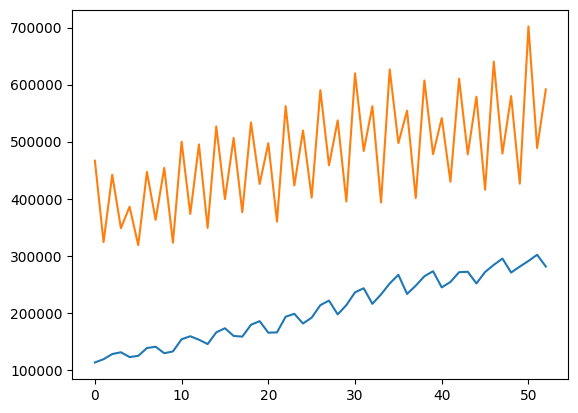

In [19]:
# ------------------------------------------------------------
# Visualización exploratoria de las series IMSS vs INEGI
# ------------------------------------------------------------

# Gráfica de la serie trimestral de empleo asegurado (IMSS)
# El objetivo es observar:
# - tendencia general
# - estacionalidad
# - posibles rupturas estructurales
comp_data["imss"].plot()

# Gráfica de la serie trimestral de PIB (INEGI)
# Se grafica sobre la misma figura por defecto,
# permitiendo una comparación visual directa entre ambas series.
comp_data["inegi"].plot()


In [20]:
# ------------------------------------------------------------
# Regresión lineal simple: IMSS ~ PIB (INEGI)
# ------------------------------------------------------------

# Se agrega explícitamente una constante (intercepto) al DataFrame.
# Esto permite estimar un modelo con término constante:
#   imss = α + β * inegi + error
comp_data["const"] = np.ones(len(comp_data))

# Se define el modelo OLS (Ordinary Least Squares):
# - Variable dependiente: empleo asegurado (IMSS)
# - Variable explicativa: PIB (INEGI)
# - Incluye intercepto ('const')
#
# NOTA:
# Se pasan los valores como arreglos NumPy, no como Series con índice,
# por lo que la alineación depende exclusivamente del orden de las filas.
model = sm.OLS(
    comp_data.loc[:, "imss"].values,
    comp_data.loc[:, ["const", "inegi"]]
)

# Se ajusta el modelo por mínimos cuadrados ordinarios
res = model.fit()

# Se muestra el resumen completo de la regresión:
# coeficientes, errores estándar, R², estadísticos t, p-values, etc.
res.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     24.96
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           7.24e-06
Time:                        22:37:40   Log-Likelihood:                -644.72
No. Observations:                  53   AIC:                             1293.
Df Residuals:                      51   BIC:                             1297.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         3.7e+04   3.43e+04      1.079      0.286   -3.18e+04    1.06e+05
inegi          0.3526      0.071      4.996      0.000       0.211       0.494
==============================================================================
Omnibus:                        2.891   Durbin-Watson:                   1.317
Prob(Omnibus):                  0.236   Jarque-Bera (JB):                2.218
Skew:                           0.349   Prob(JB):                        0.330
Kurtosis:                       2.281   Cond. No.                     2.56e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.56e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Estandarizando la matriz de Coeficientes

Porcentaje de impacto entre grupos

In [21]:
coeffs_df.head()



,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,NaN,2.781495,-3.458753,-7.104543,-179.192376,2.265814,-364.268138,5.476175,1.191572,-5.778076,...,0.708653,1.623428,-2.107633,0.704252,1.033594,-1.903239,1.099309,-0.205458,-51.143319,-96277.970554
covar_s0_g2,0.066350,NaN,1.800633,-0.710890,45.402387,-2.164332,-3.910244,0.763846,-0.268188,0.440125,...,0.109104,-0.242926,-0.163309,-0.090706,-0.122424,0.276460,-0.741253,0.023952,-10.343583,42473.845127
covar_s0_g3,-0.001273,0.027792,NaN,-0.007238,1.112674,0.237358,-2.895956,-0.118595,-0.006022,-0.009139,...,0.000625,0.016691,0.023521,0.000021,0.012079,-0.034793,0.074229,0.012535,2.082301,-3877.108265
covar_s0_g4,-0.015790,-0.066236,-0.043693,NaN,-8.281417,-0.147475,-4.890157,-0.097981,-0.020889,-0.024040,...,0.052873,-0.027257,-0.066879,0.010675,-0.002884,-0.112419,-0.012664,-0.016230,-0.568444,7245.316894
covar_s0_g5,-0.000116,0.001230,0.001953,-0.002408,NaN,-0.009839,-0.085564,-0.001014,0.001081,0.000506,...,-0.000020,-0.000052,-0.000154,0.000517,-0.000278,-0.000082,0.000159,-0.000638,-0.036296,-16.104273


In [22]:
coeffs_df = coeffs_df.fillna(0)
coeffs_std = coeffs_df.div(coeffs_df.abs().sum(axis=1), axis=0)
coeffs_df.head()

,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,0.000000,2.781495,-3.458753,-7.104543,-179.192376,2.265814,-364.268138,5.476175,1.191572,-5.778076,...,0.708653,1.623428,-2.107633,0.704252,1.033594,-1.903239,1.099309,-0.205458,-51.143319,-96277.970554
covar_s0_g2,0.066350,0.000000,1.800633,-0.710890,45.402387,-2.164332,-3.910244,0.763846,-0.268188,0.440125,...,0.109104,-0.242926,-0.163309,-0.090706,-0.122424,0.276460,-0.741253,0.023952,-10.343583,42473.845127
covar_s0_g3,-0.001273,0.027792,0.000000,-0.007238,1.112674,0.237358,-2.895956,-0.118595,-0.006022,-0.009139,...,0.000625,0.016691,0.023521,0.000021,0.012079,-0.034793,0.074229,0.012535,2.082301,-3877.108265
covar_s0_g4,-0.015790,-0.066236,-0.043693,0.000000,-8.281417,-0.147475,-4.890157,-0.097981,-0.020889,-0.024040,...,0.052873,-0.027257,-0.066879,0.010675,-0.002884,-0.112419,-0.012664,-0.016230,-0.568444,7245.316894
covar_s0_g5,-0.000116,0.001230,0.001953,-0.002408,0.000000,-0.009839,-0.085564,-0.001014,0.001081,0.000506,...,-0.000020,-0.000052,-0.000154,0.000517,-0.000278,-0.000082,0.000159,-0.000638,-0.036296,-16.104273


In [23]:
# Se aplica una transformación fila por fila (axis=1) sobre la matriz de coeficientes.
# Cada fila x corresponde a los coeficientes estimados para una regresión específica
# (es decir, para un grupo/sector explicado por los demás).
coeffs_std = coeffs_df.apply(lambda x: x / sum(abs(x)), axis=1)
coeffs_std

,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,0.000000e+00,0.000029,-0.000036,-0.000073,-0.001847,0.000023,-0.003755,0.000056,1.228314e-05,-0.000060,...,7.305043e-06,1.673486e-05,-2.172622e-05,7.259676e-06,1.065464e-05,-0.000020,1.133205e-05,-2.117933e-06,-0.000527,-0.992467
covar_s0_g2,1.558958e-06,0.000000,0.000042,-0.000017,0.001067,-0.000051,-0.000092,0.000018,-6.301303e-06,0.000010,...,2.563499e-06,-5.707760e-06,-3.837078e-06,-2.131205e-06,-2.876463e-06,0.000006,-1.741636e-05,5.627788e-07,-0.000243,0.997958
covar_s0_g3,-3.277711e-07,0.000007,0.000000,-0.000002,0.000286,0.000061,-0.000745,-0.000031,-1.549931e-06,-0.000002,...,1.609364e-07,4.296282e-06,6.054162e-06,5.398922e-09,3.109138e-06,-0.000009,1.910609e-05,3.226455e-06,0.000536,-0.997946
covar_s0_g4,-2.174118e-06,-0.000009,-0.000006,0.000000,-0.001140,-0.000020,-0.000673,-0.000013,-2.876123e-06,-0.000003,...,7.279882e-06,-3.752950e-06,-9.208326e-06,1.469819e-06,-3.970408e-07,-0.000015,-1.743633e-06,-2.234634e-06,-0.000078,0.997578
covar_s0_g5,-7.104984e-06,0.000075,0.000120,-0.000148,0.000000,-0.000604,-0.005250,-0.000062,6.635483e-05,0.000031,...,-1.239439e-06,-3.170560e-06,-9.464078e-06,3.173356e-05,-1.705920e-05,-0.000005,9.727298e-06,-3.914006e-05,-0.002227,-0.988116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
covar_s9_g91,2.790753e-06,-0.000014,0.000089,-0.000004,-0.001162,-0.000047,0.001071,-0.000010,1.344324e-06,0.000011,...,-3.541121e-06,-8.311735e-06,-2.760594e-06,3.838819e-07,0.000000e+00,0.000004,-2.543829e-07,-4.285514e-07,0.000604,0.996413
covar_s9_g92,-1.338411e-06,0.000008,-0.000066,-0.000036,-0.000090,0.000129,0.002466,0.000009,4.075701e-06,-0.000020,...,-9.822587e-08,7.234563e-07,-4.747986e-06,-4.734922e-06,9.312551e-07,0.000000,2.975809e-05,-5.864572e-07,0.000711,-0.995768
covar_s9_g93,5.099797e-07,-0.000014,0.000094,-0.000003,0.000114,-0.000117,-0.000432,0.000016,-4.471994e-06,0.000018,...,-1.741840e-06,2.246946e-06,2.777691e-06,2.423356e-07,-4.370686e-08,0.000020,0.000000e+00,-3.233959e-06,-0.000951,0.997829
covar_s9_g94,-7.004383e-07,0.000003,0.000116,-0.000025,-0.003365,-0.000114,0.000906,0.000007,3.796471e-06,0.000005,...,-1.932873e-06,2.631607e-07,1.244255e-05,-2.728446e-07,-5.411008e-07,-0.000003,-2.376556e-05,0.000000e+00,-0.000722,0.994188


### Lineas de tendencia sectoriales


In [24]:
# ------------------------------------------------------------
# Selección de observaciones de diciembre y agregación anual
# ------------------------------------------------------------

# Se convierte explícitamente la columna "Año" a formato datetime.
# Esto permite extraer componentes temporales como el mes.
selected_data["Año"] = pd.to_datetime(selected_data["Año"])

# Se filtran únicamente las observaciones correspondientes al mes de diciembre.
# La idea implícita es usar diciembre como un "representante anual"
# del nivel de empleo asegurado de cada sector.
dec_data = (
    selected_data[selected_data["Año"].dt.month == 12]
        # Se agrupa por Año y sector principal
        .groupby(["Año", "sector_economico_1"])
        # Se suman las variables numéricas dentro de cada grupo
        .sum()
        # Se elimina la columna sector_economico_2, ya que no es relevante
        # después de la agregación anual por sector principal
        .drop("sector_economico_2", axis=1)
        # Se reinicia el índice para obtener un DataFrame plano
        .reset_index()
)

# Se muestra el DataFrame resultante
dec_data


,Año,sector_economico_1,ta
0,2010-12-31,0.0,57000.936713
1,2010-12-31,1.0,2179.192215
2,2010-12-31,2.0,151602.027532
3,2010-12-31,3.0,163108.305877
4,2010-12-31,4.0,88007.498456
...,...,...,...
125,2022-12-31,5.0,9672.675313
126,2022-12-31,6.0,374868.453596
127,2022-12-31,7.0,92834.640013
128,2022-12-31,8.0,352071.114729


In [25]:
# ------------------------------------------------------------
# Carga y preparación de datos de PIB estatal (Jalisco) por actividad
# ------------------------------------------------------------

# Se carga un archivo de Excel con datos de PIB de Jalisco por actividad económica.
# El parámetro skiprows=4 indica que las primeras 4 filas del archivo
# contienen encabezados, notas o metadatos que no forman parte de los datos tabulares.
pib_jal = pd.read_excel(
    "/content/drive/MyDrive/PAP/pib_jalisco_actividad.xlsx",
    skiprows=4
)

# Se selecciona un subconjunto del DataFrame:
# - Filas: se eliminan la primera y las últimas tres filas
#   (totales, notas o renglones no informativos).
# - Columnas: se conservan solo las primeras 20 columnas
#   (posiblemente años + columna de concepto).
pib_jal = pib_jal.iloc[1:-3, :20]

# Se eliminan las columnas correspondientes a los años 2003–2009.
# Esto restringe la cobertura temporal del PIB para alinearla
# con el periodo disponible en los datos de empleo asegurado.
pib_jal = pib_jal.drop([x for x in range(2003, 2010)], axis=1)

# ------------------------------------------------------------
# Limpieza y codificación del concepto de actividad
# ------------------------------------------------------------

# La columna "Concepto" contiene la descripción de la actividad económica.
# Aquí se transforma tomando:
# - el string,
# - eliminando espacios al inicio y al final,
# - y quedándose solo con el primer carácter.
#
# El resultado parece ser un código corto (letra o número)
# que identifica la actividad económica.
#
# TODO (DOCUMENTAR):
# - Verificar qué representa exactamente este primer carácter:
#   ¿una sección del SCIAN?, ¿una categoría agregada?, ¿un código interno?
pib_jal["Concepto"] = pib_jal["Concepto"].map(lambda x: x.strip()[0])

# ------------------------------------------------------------
# Agregación del PIB por concepto
# ------------------------------------------------------------

# Se agrupa el PIB por "Concepto" y se suman las columnas numéricas (años).
# Esto produce el PIB total por actividad económica para cada año,
# agregando posibles subactividades que compartan el mismo código.
pib_jal.groupby(["Concepto"]).sum()


,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Concepto,,,,,,,,,,,,
1,55802.037,52703.563,57514.461,57476.853,61023.777,62310.448,63564.395,67405.231,69931.177,71047.971,72836.639,73488.856
2,91381.563,98572.658,100149.993,99060.425,97729.501,106121.532,107657.844,110405.913,106195.835,101547.296,92524.090,97191.221
3,191863.576,190922.894,201183.253,211593.082,238602.489,249271.344,248424.317,252011.801,257487.448,262507.240,236406.206,249075.726
4,240498.649,256633.597,266364.129,271981.065,280923.321,288495.501,311282.417,312365.142,328855.823,328698.509,293733.749,323696.969
5,207419.580,213956.632,222809.856,229693.342,236543.118,248785.968,261743.874,274661.539,284391.414,290842.862,290755.959,291885.663
6,58631.273,59713.103,61538.704,62341.499,61396.156,59909.144,62444.693,62740.882,63930.058,65173.043,62063.293,63682.149
7,27178.931,27718.800,28551.476,29935.187,34748.828,33429.554,35983.321,37997.084,38111.677,37497.564,21814.024,31695.763
8,20814.163,20608.957,21729.407,21578.545,21746.671,21979.821,23187.895,23524.507,23563.235,23762.839,20534.547,20769.771
9,31782.065,32317.852,35444.720,34918.609,34542.901,34581.558,34840.792,35503.935,35609.355,35658.372,35537.366,35432.846


In [26]:
# ------------------------------------------------------------
# Regresiones lineales sector por sector: empleo (IMSS) vs PIB (Jalisco)
# ------------------------------------------------------------

# Se calcula la longitud de la serie de PIB disponible para un sector.
# Aquí se toma la fila 0 y se omite la primera columna (probablemente "Concepto").
# El resultado suele ser el número de años disponibles (o periodos) en PIB.
len_data = len(pib_jal.iloc[0, 1:])

# Lista para guardar parámetros estimados de cada regresión por sector
lin_models = []

# Se itera por sector (0 a 9), asumiendo que hay 10 sectores/categorías
for sector in range(10):

    # --------------------------------------------------------
    # Variable explicativa (X): PIB del sector 'sector'
    # --------------------------------------------------------
    # Se toman los valores de PIB desde la columna 1 en adelante (años),
    # se convierten a float32 y se reacomodan como vector 1D.
    #
    # Se multiplica por 1,000,000:
    # Esto sugiere que el PIB está en millones y se busca pasarlo a unidades base
    # (por ejemplo, pesos en lugar de millones de pesos).
    x = pib_jal.iloc[sector, 1:].values.astype(np.float32).reshape(-1, ) * 1_000_000

    # --------------------------------------------------------
    # Variable dependiente (Y): empleo asegurado de diciembre para ese sector
    # --------------------------------------------------------
    # Se filtra dec_data al sector correspondiente y se toma la columna 'ta'.
    # Se recorta a len_data para asegurar que Y tenga la misma longitud que X.
    #
    # IMPORTANTE:
    # - Se asume implícitamente que el orden de los años en dec_data coincide con el de pib_jal.
    # - No hay un merge explícito por año; es alineación por posición.
    y = dec_data[dec_data["sector_economico_1"] == sector].ta[:len_data].values

    # Se arma un DataFrame con la X (PIB) para usarlo en statsmodels.
    # Nota: no se incluye constante (intercepto) en la regresión.
    # El comentario sugiere que consideraron incluirla:
    #   pd.DataFrame({"x": x, "const": np.ones(len(x))})
    x_df = pd.DataFrame({"x": x})

    # --------------------------------------------------------
    # Ajuste del modelo OLS
    # --------------------------------------------------------
    # Se estima un modelo lineal sin intercepto:
    #   y = β * x + error
    model = sm.OLS(y, x_df)
    res = model.fit()

    # Se guardan los parámetros estimados (β) en la lista
    lin_models.append(res.params)

    # Se imprime el R² de cada modelo (medida de ajuste)
    print(res.rsquared)


0.9878731228647721
0.9622338762655316
0.9977327262320028
0.9698399009100737
0.9887396571341793
0.9804883505310713
0.9866627146016933
0.9752534972446509
0.9795475317790069
0.9997390611899907


In [27]:
# ------------------------------------------------------------
# Inspección puntual de coeficientes estimados
# ------------------------------------------------------------

# Se muestra el parámetro estimado (beta) de la regresión
# correspondiente al sector 0.
#
# Este paso es únicamente exploratorio y sirve para:
# - verificar el orden de magnitud del coeficiente,
# - confirmar coherencia con las unidades del PIB (escalado previo),
# - realizar una revisión manual rápida del resultado.
#
# NOTA:
# Este valor no se utiliza posteriormente en el análisis,
# ni forma parte del ajuste o estandarización de la matriz de coeficientes.
lin_models[0]


,0
x,0.000001


In [28]:
# ------------------------------------------------------------
# Resumen de coeficientes PIB → Empleo por sector
# ------------------------------------------------------------

# A partir de la lista 'lin_models', que contiene los parámetros
# estimados de las regresiones sectoriales, se extrae el coeficiente
# asociado a la variable 'x' (PIB) para cada sector.
#
# El resultado es un DataFrame donde:
# - cada fila representa un sector económico,
# - la columna 'x' contiene el coeficiente beta estimado,
#   que mide la sensibilidad del empleo asegurado frente al PIB.
#
# NOTA:
# Estos coeficientes se utilizan como un resumen descriptivo
# y no alimentan directamente la matriz de coeficientes estandarizada.
pd.DataFrame({
    "x": list(map(lambda x: x.x, lin_models))
})


,x
0,1.222731e-06
1,1.071112e-06
2,1.159500e-05
3,2.450361e-06
4,4.973243e-07
5,7.643519e-08
6,2.498209e-06
7,3.229556e-06
8,7.273575e-06
9,1.711159e-06


In [29]:
# ------------------------------------------------------------
# Exportación de la matriz estandarizada para uso en Excel
# ------------------------------------------------------------

# Se transforma la matriz de coeficientes estandarizados a formato texto
# reemplazando el punto decimal por coma, para compatibilidad con Excel
# en configuraciones regionales en español.
#
# NOTA:
# Este paso es únicamente de formato y presentación.
# No modifica los valores ni afecta el análisis estadístico.
coeffs_std.applymap(lambda x: str(x).replace(".", ",")) #.to_clipboard(), pero en colab no funciona


/tmp/ipykernel_260/1379877865.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coeffs_std.applymap(lambda x: str(x).replace(".", ",")) #.to_clipboard(), pero en colab no funciona


,covar_s0_g1,covar_s0_g2,covar_s0_g3,covar_s0_g4,covar_s0_g5,covar_s1_g11,covar_s1_g12,covar_s1_g13,covar_s2_g20,covar_s2_g21,...,covar_s8_g86,covar_s8_g87,covar_s8_g88,covar_s8_g89,covar_s9_g91,covar_s9_g92,covar_s9_g93,covar_s9_g94,covar_s9_g99,intercept
covar_s0_g1,"0,0","2,867261802116555e-05","-3,565402307915041e-05","-7,32360932774577e-05","-0,0018471772554238377","2,335679311157584e-05","-0,003755002507703455","5,64503113397427e-05","1,228313832816003e-05","-5,956241038582495e-05",...,"7,30504306839433e-06","1,6734864888830157e-05","-2,1726215521124823e-05","7,259676153874131e-06","1,0654644318925125e-05","-1,96192520943071e-05","1,1332054152059296e-05","-2,117932552712769e-06","-0,0005272031005864482","-0,9924667651304618"
covar_s0_g2,"1,5589576337996446e-06","0,0","4,230736455692947e-05","-1,6702944636644996e-05","0,0010667668477616764","-5,085279185639427e-05","-9,187444286627965e-05","1,7947199521490837e-05","-6,301303350938302e-06","1,0341096544475798e-05",...,"2,5634992248687363e-06","-5,707760033833716e-06","-3,8370782397498906e-06","-2,1312046991172813e-06","-2,8764630608433138e-06","6,495661156505592e-06","-1,741635688975576e-05","5,627787884714231e-07","-0,00024303108794923047","0,9979583177247642"
covar_s0_g3,"-3,2777105060238725e-07","7,153376122608227e-06","0,0","-1,862947195728876e-06","0,0002863958691284958","6,109455668493923e-05","-0,000745402759581219","-3,0525737802526e-05","-1,5499305525487946e-06","-2,352325870683102e-06",...,"1,6093640221370184e-07","4,296282152929445e-06","6,054162391382948e-06","5,398922225195629e-09","3,109138036703904e-06","-8,955592983928638e-06","1,9106092294029545e-05","3,2264553976790136e-06","0,0005359723903950491","-0,9979457453124455"
covar_s0_g4,"-2,1741180515284245e-06","-9,119773042989983e-06","-6,015842342344096e-06","0,0","-0,0011402343652302945","-2,0305248974063716e-05","-0,0006733056532734417","-1,3490635554696773e-05","-2,8761229146517933e-06","-3,3099454706245706e-06",...,"7,279882134221862e-06","-3,752949988264787e-06","-9,208325900564396e-06","1,4698186474486497e-06","-3,970408024912682e-07","-1,5478449779304086e-05","-1,7436326941075058e-06","-2,234634061348493e-06","-7,826673331394541e-05","0,997577934932688"
covar_s0_g5,"-7,104984383431106e-06","7,546700275085136e-05","0,00011982825997153167","-0,00014773749413789914","0,0","-0,0006036743199973136","-0,005249977363635487","-6,219149413894401e-05","6,635483133843801e-05","3,101647839936983e-05",...,"-1,2394392901015014e-06","-3,1705596386341343e-06","-9,46407813304644e-06","3,1733559708194806e-05","-1,7059201147578375e-05","-5,0554724742383585e-06","9,727297758526262e-06","-3,914006278737819e-05","-0,002227020789182808","-0,988116440795179"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
covar_s9_g91,"2,790753323524495e-06","-1,3857163192358679e-05","8,858505236832244e-05","-3,5031576453885524e-06","-0,001161680311930929","-4,681486669380955e-05","0,0010711785057695745","-9,698889543052063e-06","1,3443243754124949e-06","1,0623113556834102e-05",...,"-3,5411209609047672e-06","-8,31173454062164e-06","-2,7605937485451488e-06","3,83881937992529e-07","0,0","3,575560670080504e-06","-2,543828531339966e-07","-4,285513780794777e-07","0,0006043354796037391","0,9964128010200556"
covar_s9_g92,"-1,3384108262984705e-06","8,150108518999247e-06","-6,645677909369914e-05","-3,5569397014314366e-05","-8,966319045304111e-05","0,00012904292896431192","0,0024662021706421456","8,815324226220988e-06","4,075701457936951e-06","-1,9813223960826787e-05",...,"-9,822586970504883e-08","7,234562852834314e-07","-4,747985846385102e-06","-4,734922344930945e-06","9,312550709334001e-07","0,0","2,9758094815512845e-05","-5,864572153491448e-07","0,0007110185685880903","-0,9957677656017526"
covar_s9_g93,"5,099796966689686e-07","-1,4415662189931412e-05","9,353067411876727e-05","-2,6432685942581773e-06","0,00011381038694373635","-0,00011702910643304625","-0,0004317392407885754","1,6317439563052223e-05","-4,47199

In [30]:
# ------------------------------------------------------------
# Cálculo de participaciones relativas de empleo por sector y año
# ------------------------------------------------------------

# Se fija un año y un sector económico específicos
year = 2021
sector = 0

# Se calcula el total de empleo asegurado ('ta') del sector seleccionado
# en el mes de diciembre del año indicado.
tsum = selected_data[
    (selected_data["Año"].dt.month == 12) &
    (selected_data["Año"].dt.year == year) &
    (selected_data["sector_economico_1"] == sector)
]["ta"].sum()

# Se calcula la participación relativa de cada observación dentro del total sectorial,
# dividiendo el empleo individual entre el total del sector.
#
# NOTA:
# Este cálculo es puntual y descriptivo.
# Se utiliza únicamente para obtener porcentajes de participación
# y exportarlos para análisis o presentación externa (por ejemplo, en Excel).
ta_data=(
    selected_data[
        (selected_data["Año"].dt.month == 12) &
        (selected_data["Año"].dt.year == year) &
        (selected_data["sector_economico_1"] == sector)
    ]["ta"] / tsum)#.to_clipboard(), en colab, clipboard no funciona
ta_data


,ta
142,0.788432
304,0.202855
466,0.004136
628,0.004217
790,0.000360


In [31]:
Modelos = pd.read_excel("/content/drive/MyDrive/PAP/DPESPAP.xlsx", sheet_name="Modelos")
Sheet1 = pd.read_excel("/content/drive/MyDrive/PAP/DPESPAP.xlsx", sheet_name="Sheet1")
Coeficientes = pd.read_excel("/content/drive/MyDrive/PAP/DPESPAP.xlsx", sheet_name="Coeficientes")
Coeficientes.drop(columns=["Unnamed: 0"], inplace=True)
Coeficientes

,AGRICULTURA,GANADERIA,SILVICULTURA,PESCA,CAZA,EXTRACCION BENEF. DE CARBON MINERAL GRAFITO EXCEPT,EXPLORACION Y EXTRACCION DE PETROLEO CRUDO Y GAS N,EXTRACCION Y BENEFICIO DE MINERALES METALICOS,ELABORACION DE ALIMENTOS,ELABORACION DE BEBIDAS,...,SERVICIOS DE ALQUILER; EXCEPTO DE INMUEBLES,SERVICIOS DE ALOJAMIENTO TEMPORAL,PREPARACION Y SERVICIO DE ALIMENTOS Y BEBIDAS,SERVICIOS RECREATIVOS Y DE ESPARCIMIENTO,SERVICIOS PERSONALES PARA EL HOGAR Y DIVERSOS,"SERVS.DE ENSENANZA,INVEST.CIENT.Y DIFUSION CULTURA","SERVICIOS MEDICOS,ASISTENCIA SOCIAL Y VETERINARIOS","AGRUP.MERC.,PROF.CIVICAS,POLITICAS,LABOR Y RELIG.",SERVICIOS DE ADMINISTRACION PUBLICA Y SEGURIDAD SO,SERV. DE ORGANIZACIONES INTERNACIONALES Y EXTRATER
0,9.840963e-01,2.825282e-06,-0.000063,-0.000050,0.010157,-0.000134,0.005137,4.978304e-05,-7.557931e-07,-1.448119e-06,...,2.517317e-07,1.601005e-07,3.158113e-07,2.673621e-07,-3.045974e-07,-2.371567e-07,6.638278e-07,-1.403507e-06,-7.257813e-08,-0.000050
1,9.289013e-07,9.925830e-01,-0.000146,0.000149,0.003332,-0.000062,0.003591,-8.495286e-07,-1.251431e-07,-1.103226e-08,...,2.836958e-06,-2.187577e-07,-6.788033e-08,-1.881922e-07,-6.163171e-08,-1.629318e-07,7.399708e-07,-3.852915e-06,5.291855e-08,-0.000040
2,-5.474493e-08,-1.241722e-06,0.992274,-0.000255,0.002483,0.000034,-0.004719,7.070397e-05,-7.212906e-07,-7.308376e-07,...,-2.413019e-06,6.422801e-07,2.048886e-07,7.110022e-07,-1.499195e-07,2.777221e-08,-8.549892e-07,6.035315e-06,-1.539803e-07,0.000049
3,-4.870939e-08,4.996106e-06,-0.000571,0.977026,0.014302,-0.000061,0.005753,-3.673243e-04,5.508394e-06,5.125784e-06,...,6.775397e-06,-2.758150e-06,-1.695350e-06,-2.766661e-06,2.416916e-06,-3.224453e-07,7.097413e-06,-3.109763e-05,6.074606e-07,0.000415
4,6.357597e-06,-1.221925e-05,-0.000311,0.000579,0.982596,-0.000132,0.014814,1.895945e-05,1.152501e-06,-6.141640e-06,...,1.379763e-07,-9.728356e-07,1.194806e-06,-1.160653e-06,-5.888811e-07,-7.545284e-07,3.122108e-06,-2.178617e-05,0.000000e+00,0.000256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,4.913323e-07,-1.422481e-06,0.000025,-0.000195,0.003714,-0.000020,0.000947,2.355159e-05,-3.743936e-07,-5.804236e-07,...,-6.925265e-07,1.387899e-07,1.810259e-07,2.210157e-07,-2.042908e-07,9.949157e-01,-3.965464e-07,1.803311e-06,-4.779074e-08,-0.000027
57,1.363566e-06,-2.335987e-06,-0.000086,0.000223,0.004230,-0.000095,0.000890,1.984254e-05,-3.326005e-08,-3.251547e-08,...,3.485805e-06,2.572834e-07,-7.576928e-08,1.798032e-07,-1.303294e-07,-2.722158e-07,9.941262e-01,1.049660e-06,-1.632674e-08,0.000005
58,2.224529e-07,-1.407341e-06,0.000088,-0.000284,0.001484,0.000019,-0.000691,7.302890e-05,-1.137706e-06,-7.370085e-07,...,-1.247073e-06,5.476783e-07,9.693801e-08,1.050138e-06,-1.134784e-07,-1.474263e-07,5.691694e-08,9.970232e-01,2.993820e-09,0.000065
59,4.009587e-07,-8.670774e-07,-0.000008,-0.000035,0.001799,-0.000019,0.000559,2.306467e-05,-3.495590e-07,-3.511436e-07,...,-5.064531e-08,5.707416e-08,5.391701e-08,1.937149e-07,-5.210784e-08,-8.185007e-08,1.551054e-07,5.540265e-07,9.974129e-01,-0.000050


In [32]:
import json
from IPython.display import HTML, display

# ============================================================
#  ⬇️  PASO 1: REEMPLAZA AQUÍ TUS VARIABLES DE PYTHON
# ============================================================

# 🔷 TU LISTA DE SECTORES (61 nombres)
#    Reemplaza: tu_lista_sectores → tu variable Python con los nombres
#    Ejemplo:   sectores_nombres = list(df_sectores["nombre"])
sectores_nombres = Modelos["Grupo"]          # <-- CAMBIA ESTO

# 🔷 COEFICIENTE INDIVIDUAL POR SECTOR (vector de 61 elementos)
#    Reemplaza: tu_vector_coef → tu variable (list o numpy array)
#    Ejemplo:   coef = list(df_sectores["coef"])
coef = list(Modelos["Coeficiente"])                   # <-- CAMBIA ESTO

# 🔷 COEFICIENTE DE PARTICIPACIÓN POR SECTOR (vector de 61 elementos)
#    Reemplaza: tu_vector_coef1 → tu variable (list o numpy array)
#    Ejemplo:   coef1 = list(df_sectores["coef1"])
coef1 = list(Modelos["Coeficientes"])                 # <-- CAMBIA ESTO

# 🔷 MATRIZ DE COEFICIENTES TÉCNICOS (61x61)
#    Reemplaza: tu_matriz_coefT → tu variable (list de listas o numpy array)
#    Si es numpy:  coef_T = tu_matriz_coefT.tolist()
#    Si es lista:  coef_T = tu_matriz_coefT
coef_T = Coeficientes.values.tolist()           # <-- CAMBIA ESTO (agrega .tolist() si es numpy)

# ============================================================
#  ⬇️  PASO 2: CONSTRUCCIÓN DEL JSON (no tocar)
# ============================================================

sectores_json = json.dumps([
    {"nombre": sectores_nombres[i], "coef": coef[i], "coef1": coef1[i]}
    for i in range(len(sectores_nombres))
])
coef_t_json = json.dumps(coef_T)

# ============================================================
#  ⬇️  PASO 3: HTML + JS (no tocar)
# ============================================================

html_code = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;500;600&display=swap');
  :root {{
    --bg: #0f1117; --panel: #181c25; --border: #252a38;
    --accent: #00e5a0; --accent2: #4d9fff; --red: #ff5c5c;
    --text: #e2e8f0; --muted: #6b7280; --input-bg: #1e2332;
  }}
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ background: var(--bg); color: var(--text); font-family: 'IBM Plex Sans', sans-serif; }}

  .top-bar {{
    background: var(--panel); border-bottom: 1px solid var(--border);
    padding: 14px 28px; display: flex; align-items: center; gap: 16px;
  }}
  .top-bar h1 {{ font-family: 'IBM Plex Mono', monospace; font-size: 1rem; color: var(--accent); }}
  .top-bar span {{ font-size: 0.75rem; color: var(--muted); }}

  .layout {{ display: grid; grid-template-columns: 1fr 300px; height: calc(100vh - 53px); }}
  .main {{ overflow-y: auto; padding: 20px 24px; }}

  table {{ width: 100%; border-collapse: collapse; }}
  thead {{ position: sticky; top: 0; z-index: 10; }}
  thead th {{
    background: #1a1f2e; font-family: 'IBM Plex Mono', monospace;
    font-size: 0.65rem; color: var(--muted); text-transform: uppercase;
    letter-spacing: 0.07em; padding: 9px 12px; text-align: left;
    border-bottom: 1px solid var(--border);
  }}
  thead th:nth-child(2), thead th:nth-child(3) {{ text-align: right; }}
  tbody tr {{ border-bottom: 1px solid var(--border); transition: background 0.1s; }}
  tbody tr:hover {{ background: rgba(255,255,255,0.025); }}
  td {{ padding: 7px 12px; font-size: 0.8rem; }}
  td.name {{ color: var(--text); max-width: 0; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; width: 100%; }}
  td.inv {{ text-align: right; width: 140px; }}
  td.emp {{ text-align: right; width: 160px; font-family: "IBM Plex Mono", monospace; font-size: 0.8rem; }}
  td.emp.pos {{ color: var(--accent); }} td.emp.neg {{ color: var(--red); }} td.emp.zero {{ color: var(--muted); }}

  input[type=number] {{
    background: var(--input-bg); border: 1px solid var(--border);
    color: var(--text); font-family: "IBM Plex Mono", monospace;
    font-size: 0.78rem; padding: 5px 8px; border-radius: 4px;
    width: 120px; text-align: right; outline: none; transition: border-color 0.15s;
  }}
  input[type=number]:focus {{ border-color: var(--accent2); background: #222840; }}
  input[type=number]::-webkit-inner-spin-button {{ opacity: 0.4; }}

  .sidebar {{
    background: var(--panel); border-left: 1px solid var(--border);
    overflow-y: auto; padding: 20px 16px; display: flex; flex-direction: column; gap: 14px;
  }}
  .card {{ background: var(--bg); border: 1px solid var(--border); border-radius: 6px; padding: 14px 16px; }}
  .card-lbl {{ font-family: "IBM Plex Mono", monospace; font-size: 0.6rem; color: var(--muted); text-transform: uppercase; letter-spacing: 0.08em; margin-bottom: 6px; }}
  .card-val {{ font-family: "IBM Plex Mono", monospace; font-size: 1.7rem; font-weight: 600; line-height: 1; }}
  .card-val.green {{ color: var(--accent); }} .card-val.blue {{ color: var(--accent2); }}
  .card-sub {{ font-size: 0.68rem; color: var(--muted); margin-top: 3px; }}
  .divider {{ height: 1px; background: var(--border); }}
  .top-list {{ display: flex; flex-direction: column; gap: 6px; }}
  .top-item {{ display: flex; align-items: center; gap: 8px; font-size: 0.7rem; }}
  .top-item-name {{ flex: 1; color: var(--muted); overflow: hidden; text-overflow: ellipsis; white-space: nowrap; font-size: 0.65rem; }}
  .top-item-bar-wrap {{ width: 60px; height: 5px; background: var(--border); border-radius: 3px; flex-shrink: 0; }}
  .top-item-bar {{ height: 100%; background: var(--accent); border-radius: 3px; transition: width 0.3s; }}
  .top-item-val {{ font-family: "IBM Plex Mono", monospace; font-size: 0.65rem; width: 42px; text-align: right; color: var(--text); }}
  .reset-btn {{
    background: transparent; border: 1px solid var(--border); color: var(--muted);
    font-family: "IBM Plex Mono", monospace; font-size: 0.72rem; padding: 8px;
    border-radius: 4px; cursor: pointer; transition: all 0.15s; width: 100%;
  }}
  .reset-btn:hover {{ border-color: var(--red); color: var(--red); }}
</style>
</head>
<body>
<div class="top-bar">
  <h1>Simulador DPESPAP</h1>
  <span>Modifica Inversión (MDP) por sector → calcula Empleados Generados</span>
</div>
<div class="layout">
  <div class="main">
    <table>
      <thead><tr>
        <th>Sector</th><th>Inversión (MDP)</th><th>Empleados Generados</th>
      </tr></thead>
      <tbody id="tbody"></tbody>
    </table>
  </div>
  <div class="sidebar">
    <div class="card">
      <div class="card-lbl">Total Empleados Generados</div>
      <div class="card-val green" id="totalEmp">0</div>
      <div class="card-sub">suma de los sectores</div>
    </div>
    <div class="card">
      <div class="card-lbl">Total Inversión (MDP)</div>
      <div class="card-val blue" id="totalInv">0</div>
      <div class="card-sub">millones de pesos</div>
    </div>
    <div class="divider"></div>
    <div class="card">
      <div class="card-lbl">Top 8 por Empleados</div>
      <div class="top-list" id="topList"></div>
    </div>
    <button class="reset-btn" onclick="resetAll()">↺ Resetear todo</button>
  </div>
</div>

<script>
// Datos inyectados desde Python
const SECTORES = {sectores_json};
const COEF_T   = {coef_t_json};
const N = SECTORES.length;
const inversiones = new Array(N).fill(0);
const empleadosResult = new Array(N).fill(0);

function calcular() {{
  const estEmp = new Array(N);
  for (let i = 0; i < N; i++) {{
    const val = inversiones[i] * 1_000_000;
    estEmp[i] = val === 0 ? 0 : SECTORES[i].coef * val * SECTORES[i].coef1;
  }}
  for (let i = 0; i < N; i++) {{
    let sum = 0;
    const row = COEF_T[i];
    for (let j = 0; j < N; j++) sum += row[j] * estEmp[j];
    empleadosResult[i] = Math.floor(sum);
  }}
}}

function buildTable() {{
  const tbody = document.getElementById('tbody');
  tbody.innerHTML = '';
  for (let i = 0; i < N; i++) {{
    const tr = document.createElement('tr');
    const emp = empleadosResult[i];
    const cls = emp > 0 ? 'pos' : emp < 0 ? 'neg' : 'zero';
    tr.innerHTML = `
      <td class="name" title="${{SECTORES[i].nombre}}">${{SECTORES[i].nombre}}</td>
      <td class="inv"><input type="number" min="0" step="1" value="0" data-idx="${{i}}" oninput="handleInput(this)"></td>
      <td class="emp ${{cls}}" id="emp-${{i}}">${{emp.toLocaleString('es-MX')}}</td>`;
    tbody.appendChild(tr);
  }}
}}

function updateTable() {{
  for (let i = 0; i < N; i++) {{
    const cell = document.getElementById('emp-' + i);
    const emp = empleadosResult[i];
    cell.textContent = emp.toLocaleString('es-MX');
    cell.className = 'emp ' + (emp > 0 ? 'pos' : emp < 0 ? 'neg' : 'zero');
  }}
}}

function updateSidebar() {{
  const totalEmp = empleadosResult.reduce((a,b) => a+b, 0);
  const totalInv = inversiones.reduce((a,b) => a+b, 0);
  document.getElementById('totalEmp').textContent = totalEmp.toLocaleString('es-MX');
  document.getElementById('totalInv').textContent = totalInv.toLocaleString('es-MX', {{maximumFractionDigits:2}});
  const pairs = empleadosResult.map((e,i) => [i,e]).sort((a,b) => b[1]-a[1]).slice(0,8);
  const maxVal = pairs[0]?.[1] || 1;
  document.getElementById('topList').innerHTML = pairs.map(([i,e]) => `
    <div class="top-item">
      <span class="top-item-name" title="${{SECTORES[i].nombre}}">${{SECTORES[i].nombre}}</span>
      <div class="top-item-bar-wrap"><div class="top-item-bar" style="width:${{maxVal>0?Math.max(0,e/maxVal*100):0}}%"></div></div>
      <span class="top-item-val">${{e.toLocaleString('es-MX')}}</span>
    </div>`).join('');
}}

function handleInput(input) {{
  inversiones[parseInt(input.dataset.idx)] = parseFloat(input.value) || 0;
  calcular(); updateTable(); updateSidebar();
}}

function resetAll() {{
  for (let i = 0; i < N; i++) inversiones[i] = 0;
  document.querySelectorAll('input[data-idx]').forEach(inp => inp.value = 0);
  calcular(); updateTable(); updateSidebar();
}}

calcular(); buildTable(); updateSidebar();
</script>
</body></html>
"""

# ============================================================
#  ⬇️  PASO 4: MOSTRAR EN COLAB (no tocar)
# ============================================================
display(HTML(f'<div style="height:750px; border-radius:8px; overflow:hidden;">{html_code}</div>'))

Sector,Inversión (MDP),Empleados Generados


In [33]:
import json
from IPython.display import HTML, display

# ============================================================
#  ⬇️  PASO 1: REEMPLAZA AQUÍ TUS VARIABLES DE PYTHON
# ============================================================

# 🔷 TU LISTA DE SECTORES (61 nombres)
#    Reemplaza: tu_lista_sectores → tu variable Python con los nombres
#    Ejemplo:   sectores_nombres = list(df_sectores["nombre"])
sectores_nombres = Modelos["Grupo"]          # <-- CAMBIA ESTO

# 🔷 COEFICIENTE INDIVIDUAL POR SECTOR (vector de 61 elementos)
#    Reemplaza: tu_vector_coef → tu variable (list o numpy array)
#    Ejemplo:   coef = list(df_sectores["coef"])
coef = list(Modelos["Coeficiente"])                   # <-- CAMBIA ESTO

# 🔷 COEFICIENTE DE PARTICIPACIÓN POR SECTOR (vector de 61 elementos)
#    Reemplaza: tu_vector_coef1 → tu variable (list o numpy array)
#    Ejemplo:   coef1 = list(df_sectores["coef1"])
coef1 = list(Modelos["Coeficientes"])                 # <-- CAMBIA ESTO

# 🔷 MATRIZ DE COEFICIENTES TÉCNICOS (61x61)
#    Reemplaza: tu_matriz_coefT → tu variable (list de listas o numpy array)
#    Si es numpy:  coef_T = tu_matriz_coefT.tolist()
#    Si es lista:  coef_T = tu_matriz_coefT
coef_T = Coeficientes.values.tolist()           # <-- CAMBIA ESTO (agrega .tolist() si es numpy)


# ============================================================
#  ⬇️  PASO 2: CONSTRUCCIÓN DEL JSON (no tocar)
# ============================================================

sectores_json = json.dumps([
    {"nombre": sectores_nombres[i], "coef": coef[i], "coef1": coef1[i]}
    for i in range(len(sectores_nombres))
])
coef_t_json = json.dumps(coef_T)

# ============================================================
#  ⬇️  PASO 3: HTML + JS (no tocar)
# ============================================================

html_code = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;500;600&display=swap');
  :root {{
    --bg: #0f1117; --panel: #181c25; --border: #252a38;
    --accent: #00e5a0; --accent2: #4d9fff; --red: #ff5c5c;
    --text: #e2e8f0; --muted: #6b7280; --input-bg: #1e2332;
  }}
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ background: var(--bg); color: var(--text); font-family: 'IBM Plex Sans', sans-serif; }}

  .top-bar {{
    background: var(--panel); border-bottom: 1px solid var(--border);
    padding: 14px 28px; display: flex; align-items: center; gap: 16px;
  }}
  .top-bar h1 {{ font-family: 'IBM Plex Mono', monospace; font-size: 1rem; color: var(--accent); }}
  .top-bar span {{ font-size: 0.75rem; color: var(--muted); }}

  .layout {{ display: grid; grid-template-columns: 1fr 300px; height: calc(100vh - 53px); }}
  .main {{ overflow-y: auto; padding: 20px 24px; }}

  table {{ width: 100%; border-collapse: collapse; }}
  thead {{ position: sticky; top: 0; z-index: 10; }}
  thead th {{
    background: #1a1f2e; font-family: 'IBM Plex Mono', monospace;
    font-size: 0.65rem; color: var(--muted); text-transform: uppercase;
    letter-spacing: 0.07em; padding: 9px 12px; text-align: left;
    border-bottom: 1px solid var(--border);
  }}
  thead th:nth-child(2), thead th:nth-child(3) {{ text-align: right; }}
  tbody tr {{ border-bottom: 1px solid var(--border); transition: background 0.1s; }}
  tbody tr:hover {{ background: rgba(255,255,255,0.025); }}
  td {{ padding: 7px 12px; font-size: 0.8rem; }}
  td.name {{ color: var(--text); max-width: 0; overflow: hidden; text-overflow: ellipsis; white-space: nowrap; width: 100%; }}
  td.inv {{ text-align: right; width: 140px; }}
  td.emp {{ text-align: right; width: 160px; font-family: "IBM Plex Mono", monospace; font-size: 0.8rem; }}
  td.emp.pos {{ color: var(--accent); }} td.emp.neg {{ color: var(--red); }} td.emp.zero {{ color: var(--muted); }}

  input[type=number] {{
    background: var(--input-bg); border: 1px solid var(--border);
    color: var(--text); font-family: "IBM Plex Mono", monospace;
    font-size: 0.78rem; padding: 5px 8px; border-radius: 4px;
    width: 120px; text-align: right; outline: none; transition: border-color 0.15s;
  }}
  input[type=number]:focus {{ border-color: var(--accent2); background: #222840; }}
  input[type=number]::-webkit-inner-spin-button {{ opacity: 0.4; }}

  .sidebar {{
    background: var(--panel); border-left: 1px solid var(--border);
    overflow-y: auto; padding: 20px 16px; display: flex; flex-direction: column; gap: 14px;
  }}
  .card {{ background: var(--bg); border: 1px solid var(--border); border-radius: 6px; padding: 14px 16px; }}
  .card-lbl {{ font-family: "IBM Plex Mono", monospace; font-size: 0.6rem; color: var(--muted); text-transform: uppercase; letter-spacing: 0.08em; margin-bottom: 6px; }}
  .card-val {{ font-family: "IBM Plex Mono", monospace; font-size: 1.7rem; font-weight: 600; line-height: 1; }}
  .card-val.green {{ color: var(--accent); }} .card-val.blue {{ color: var(--accent2); }}
  .card-sub {{ font-size: 0.68rem; color: var(--muted); margin-top: 3px; }}
  .divider {{ height: 1px; background: var(--border); }}
  .top-list {{ display: flex; flex-direction: column; gap: 6px; }}
  .top-item {{ display: flex; align-items: center; gap: 8px; font-size: 0.7rem; }}
  .top-item-name {{ flex: 1; color: var(--muted); overflow: hidden; text-overflow: ellipsis; white-space: nowrap; font-size: 0.65rem; }}
  .top-item-bar-wrap {{ width: 60px; height: 5px; background: var(--border); border-radius: 3px; flex-shrink: 0; }}
  .top-item-bar {{ height: 100%; background: var(--accent); border-radius: 3px; transition: width 0.3s; }}
  .top-item-val {{ font-family: "IBM Plex Mono", monospace; font-size: 0.65rem; width: 42px; text-align: right; color: var(--text); }}
  .reset-btn {{
    background: transparent; border: 1px solid var(--border); color: var(--muted);
    font-family: "IBM Plex Mono", monospace; font-size: 0.72rem; padding: 8px;
    border-radius: 4px; cursor: pointer; transition: all 0.15s; width: 100%;
  }}
  .reset-btn:hover {{ border-color: var(--red); color: var(--red); }}
</style>
</head>
<body>
<div class="top-bar">
  <h1>Simulador DPESPAP</h1>
  <span>Modifica Inversión (MDP) por sector → calcula Empleados Generados</span>
</div>
<div class="layout">
  <div class="main">
    <table>
      <thead><tr>
        <th>Sector</th><th>Inversión (MDP)</th><th>Empleados Generados</th>
      </tr></thead>
      <tbody id="tbody"></tbody>
    </table>
  </div>
  <div class="sidebar">
    <div class="card">
      <div class="card-lbl">Total Empleados Generados</div>
      <div class="card-val green" id="totalEmp">0</div>
      <div class="card-sub">suma de los sectores</div>
    </div>
    <div class="card">
      <div class="card-lbl">Total Inversión (MDP)</div>
      <div class="card-val blue" id="totalInv">0</div>
      <div class="card-sub">millones de pesos</div>
    </div>
    <div class="divider"></div>
    <div class="card">
      <div class="card-lbl">Top 8 por Empleados</div>
      <div class="top-list" id="topList"></div>
    </div>
    <button class="reset-btn" onclick="resetAll()">↺ Resetear todo</button>
  </div>
</div>

<script>
// Datos inyectados desde Python
const SECTORES = {sectores_json};
const COEF_T   = {coef_t_json};
const N = SECTORES.length;
const inversiones = new Array(N).fill(0);
const empleadosResult = new Array(N).fill(0);

function calcular() {{
  const estEmp = new Array(N);
  for (let i = 0; i < N; i++) {{
    const val = inversiones[i] * 1_000_000;
    estEmp[i] = val === 0 ? 0 : SECTORES[i].coef * val * SECTORES[i].coef1;
  }}
  for (let i = 0; i < N; i++) {{
    let sum = 0;
    const row = COEF_T[i];
    for (let j = 0; j < N; j++) sum += row[j] * estEmp[j];
    empleadosResult[i] = Math.floor(sum);
  }}
}}

function buildTable() {{
  const tbody = document.getElementById('tbody');
  tbody.innerHTML = '';
  for (let i = 0; i < N; i++) {{
    const tr = document.createElement('tr');
    const emp = empleadosResult[i];
    const cls = emp > 0 ? 'pos' : emp < 0 ? 'neg' : 'zero';
    tr.innerHTML = `
      <td class="name" title="${{SECTORES[i].nombre}}">${{SECTORES[i].nombre}}</td>
      <td class="inv"><input type="number" min="0" step="1" value="0" data-idx="${{i}}" oninput="handleInput(this)"></td>
      <td class="emp ${{cls}}" id="emp-${{i}}">${{emp.toLocaleString('es-MX')}}</td>`;
    tbody.appendChild(tr);
  }}
}}

function updateTable() {{
  for (let i = 0; i < N; i++) {{
    const cell = document.getElementById('emp-' + i);
    const emp = empleadosResult[i];
    cell.textContent = emp.toLocaleString('es-MX');
    cell.className = 'emp ' + (emp > 0 ? 'pos' : emp < 0 ? 'neg' : 'zero');
  }}
}}

function updateSidebar() {{
  const totalEmp = empleadosResult.reduce((a,b) => a+b, 0);
  const totalInv = inversiones.reduce((a,b) => a+b, 0);
  document.getElementById('totalEmp').textContent = totalEmp.toLocaleString('es-MX');
  document.getElementById('totalInv').textContent = totalInv.toLocaleString('es-MX', {{maximumFractionDigits:2}});
  const pairs = empleadosResult.map((e,i) => [i,e]).sort((a,b) => b[1]-a[1]).slice(0,8);
  const maxVal = pairs[0]?.[1] || 1;
  document.getElementById('topList').innerHTML = pairs.map(([i,e]) => `
    <div class="top-item">
      <span class="top-item-name" title="${{SECTORES[i].nombre}}">${{SECTORES[i].nombre}}</span>
      <div class="top-item-bar-wrap"><div class="top-item-bar" style="width:${{maxVal>0?Math.max(0,e/maxVal*100):0}}%"></div></div>
      <span class="top-item-val">${{e.toLocaleString('es-MX')}}</span>
    </div>`).join('');
}}

function handleInput(input) {{
  inversiones[parseInt(input.dataset.idx)] = parseFloat(input.value) || 0;
  calcular(); updateTable(); updateSidebar();
}}

function resetAll() {{
  for (let i = 0; i < N; i++) inversiones[i] = 0;
  document.querySelectorAll('input[data-idx]').forEach(inp => inp.value = 0);
  calcular(); updateTable(); updateSidebar();
}}

calcular(); buildTable(); updateSidebar();
</script>
</body></html>
"""

# ============================================================
#  ⬇️  PASO 4: GUARDAR Y DESCARGAR EL HTML (no tocar)
# ============================================================
from google.colab import files

# Guarda el archivo en el entorno de Colab
nombre_archivo = "simulador_dpespap.html"
with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(html_code)

# Descarga automática al equipo
files.download(nombre_archivo)

print(f"✅ Archivo '{nombre_archivo}' descargado.")
print("👉 Ábrelo en tu navegador — funciona igual que una página web normal.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivo 'simulador_dpespap.html' descargado.
👉 Ábrelo en tu navegador — funciona igual que una página web normal.
